In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Project/

/content/drive/MyDrive/Project


In [ ]:
%ls

 200_samples_NIDS.csv          Project.ipynb     Test_data.csv
 adversarial_dataset_200.csv  'report (1).log'   Train_data.csv
 adversarial_dataset.csv       report.log


In [ ]:
!pip install pyswarms
!pip install pyswarm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4463 sha256=b085e0087aeab06bdc6fc4e43254faa06cb625b745d51bef24258a0a3919e8b7
  Stored in directory: /root/.cache/pip/wheels/bb/4f/ec/8970b83323e16aa95034da175454843947376614d6d5e9627f
Successfully built pyswarm


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from pyswarms.single import GlobalBestPSO
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Data Loading and Preprocessing
df = pd.read_csv('Train_data.csv', header=None, low_memory=False)
df.columns = df.iloc[0]
df = df[1:]
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
1,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0,0,0,0.05,0,normal
2,0,udp,other,SF,146,0,0,0,0,0,...,1,0,0.6,0.88,0,0,0,0,0,normal
3,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.1,0.05,0,0,1,1,0,0,anomaly
4,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1,0,0.03,0.04,0.03,0.01,0,0.01,normal
5,0,tcp,http,SF,199,420,0,0,0,0,...,255,1,0,0,0,0,0,0,0,normal


In [ ]:
le = LabelEncoder()
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
1,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0,0,0,0.05,0,normal
2,0,2,41,9,146,0,0,0,0,0,...,1,0,0.6,0.88,0,0,0,0,0,normal
3,0,1,46,5,0,0,0,0,0,0,...,26,0.1,0.05,0,0,1,1,0,0,anomaly
4,0,1,22,9,232,8153,0,0,0,0,...,255,1,0,0.03,0.04,0.03,0.01,0,0.01,normal
5,0,1,22,9,199,420,0,0,0,0,...,255,1,0,0,0,0,0,0,0,normal


In [ ]:
# Define columns to exclude from attack
EXCLUDED_COLS = ['protocol_type', 'flag','service','urgent', 'land', 'hot', 'root_shell', 'num_outbound_cmds']
X = df.drop(['class'] + EXCLUDED_COLS, axis=1)
excluded_data = df[EXCLUDED_COLS]
y = le.fit_transform(df['class'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Original Model Performance:
Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3523
           1       1.00      1.00      1.00      4035

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



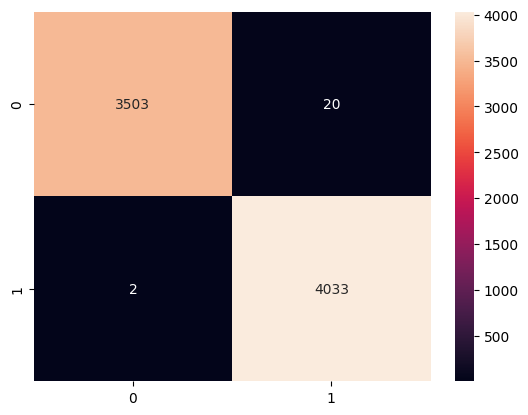

In [ ]:
# Evaluation function
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(classification_report(y, y_pred))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

# Initial evaluation
print("Original Model Performance:")
evaluate_model(rf, X_test, y_test)

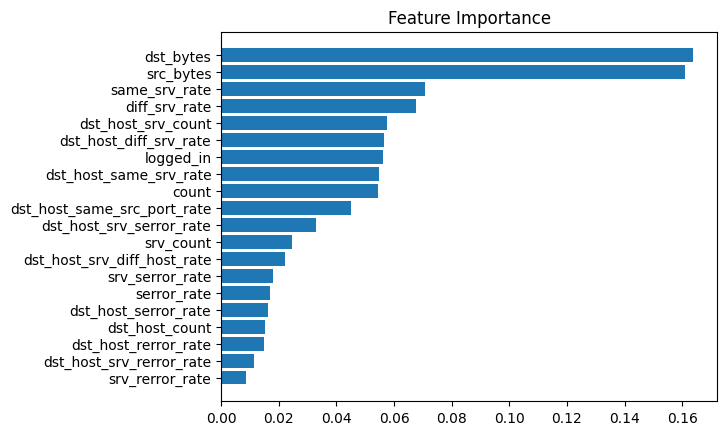

In [ ]:
# Feature importance
importances = rf.feature_importances_
features = X.columns
plt.barh(features[np.argsort(importances)[-20:]], importances[np.argsort(importances)[-20:]])
plt.title("Feature Importance")
plt.show()

In [ ]:
# Ensure all features are numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_train = X_train.dropna(axis=1)
X_test = X_test.dropna(axis=1)

# Update feature names
features = X_train.columns

In [ ]:
# PSO-based attack
def pso_attack(model, X_test, y_test):
    # PSO configuration
    options = {'c1': 0.7, 'c2': 0.4, 'w': 0.8}
    n_particles = 50
    max_iter = 200
    max_perturb = 5.0

    bounds = (np.full(X_test.shape[1], -max_perturb),
             np.full(X_test.shape[1], max_perturb))

    # Adversarial objective function
    def objective(perturbations):
        perturb_3d = perturbations.reshape((n_particles, 1, X_test.shape[1]))

        # Create perturbed dataset (n_particles, n_samples, n_features)
        perturbed_data = X_test + perturb_3d
        preds = model.predict(perturbed_data.reshape(-1, X_test.shape[1]))
        preds= preds.reshape(n_particles, -1)
        return np.mean(preds[:, y_test == 1] == 0, axis=1)

    # Initialize and run PSO
    optimizer = GlobalBestPSO(n_particles=n_particles,
                            dimensions=X_test.shape[1],
                            options=options,
                            bounds=bounds)
    cost, pos = optimizer.optimize(objective, iters=max_iter)

    return pos

In [ ]:
# Generate adversarial perturbations
print("\nGenerating adversarial perturbations with PSO...")
best_perturbation = pso_attack(rf, X_test.values, y_test)

2025-05-01 03:03:41,135 - pyswarms.single.global_best - INFO - Optimize for 200 iters with {'c1': 0.7, 'c2': 0.4, 'w': 0.8}



Generating adversarial perturbations with PSO...


pyswarms.single.global_best: 100%|██████████|200/200, best_cost=0
2025-05-01 03:09:54,640 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-3.1516193  -2.40707367 -1.18954953  2.87431749  2.86640838  1.41505477
 -0.74421948 -0.30450865 -4.63460147 -0.67161803  2.64264311  0.70699019
  3.28796742  0.44847791  1.68307538  3.71261669 -1.50444886 -0.86741958
  4.49331334 -0.67885475 -0.77995571 -3.69341767  1.74889312 -3.74678041
 -3.3911122   1.07828657 -0.34474726 -0.61847504  1.27951772  2.29269919
 -2.76385639 -2.39744449 -3.30026695]



Adversarial dataset saved as adversarial_dataset.csv

Evaluating Original Model on Adversarial Data:
Accuracy: 0.5401
              precision    recall  f1-score   support

           0       1.00      0.01      0.03      3523
           1       0.54      1.00      0.70      4035

    accuracy                           0.54      7558
   macro avg       0.77      0.51      0.36      7558
weighted avg       0.75      0.54      0.39      7558



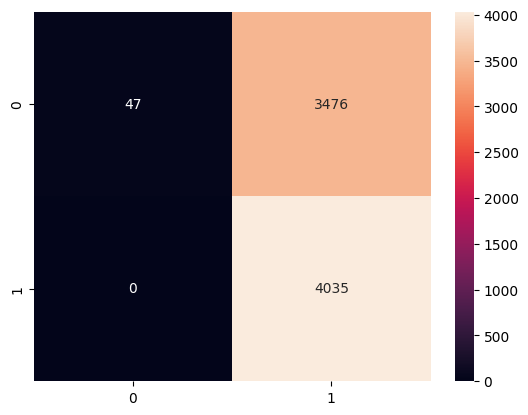

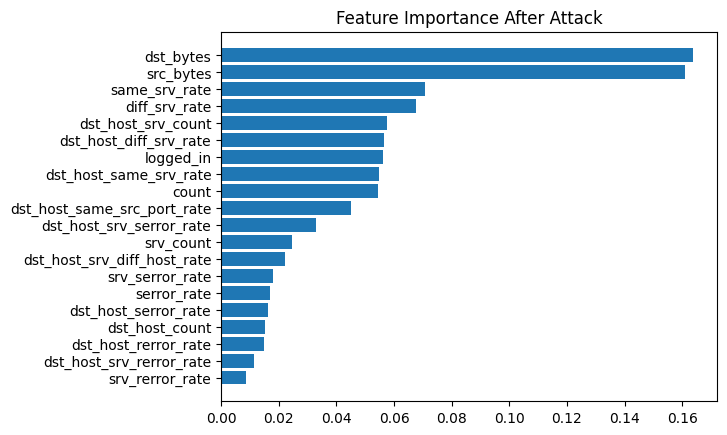

In [ ]:
# Create adversarial dataset
X_adv = X_test.copy()
X_adv.iloc[:, :] = X_test.values + best_perturbation

# Save adversarial dataset
adv_filename = 'adversarial_dataset.csv'
X_adv.to_csv(adv_filename, index=False)
print(f"\nAdversarial dataset saved as {adv_filename}")

# Evaluate original model on adversarial data
print("\nEvaluating Original Model on Adversarial Data:")
evaluate_model(rf, X_adv, y_test)

# Feature importance after attack
importances_adv = rf.feature_importances_
plt.barh(features[np.argsort(importances_adv)[-20:]],
        importances_adv[np.argsort(importances_adv)[-20:]])
plt.title("Feature Importance After Attack")
plt.show()

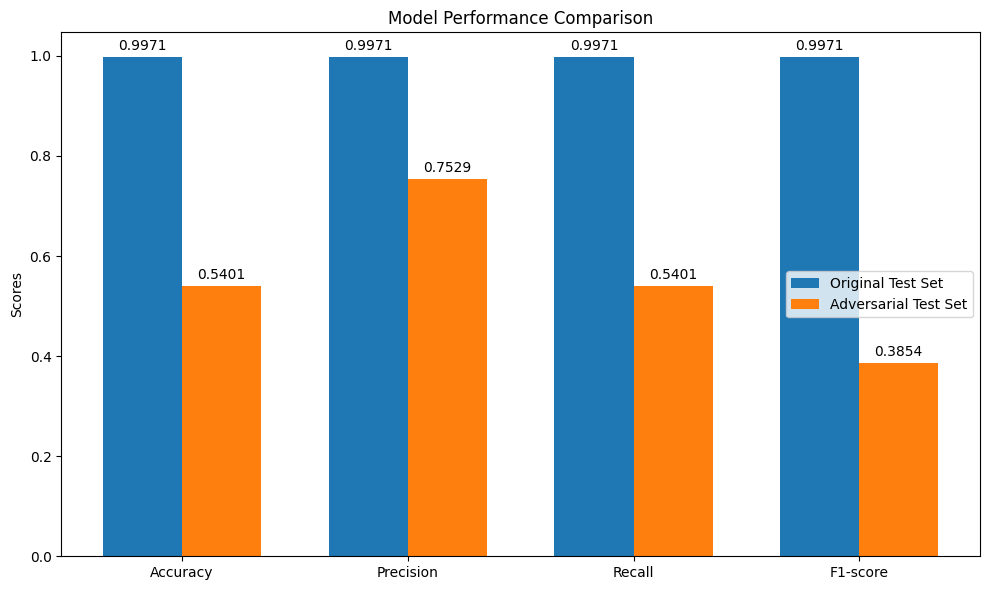

In [ ]:

# Evaluate and get accuracy, precision, recall, and F1 scores
y_pred_orig = rf.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)
prec_orig = precision_score(y_test, y_pred_orig, average='weighted')
rec_orig = recall_score(y_test, y_pred_orig, average='weighted')
f1_orig = f1_score(y_test, y_pred_orig, average='weighted')

y_pred_adv = rf.predict(X_adv)
acc_adv = accuracy_score(y_test, y_pred_adv)
prec_adv = precision_score(y_test, y_pred_adv, average='weighted')
rec_adv = recall_score(y_test, y_pred_adv, average='weighted')
f1_adv = f1_score(y_test, y_pred_adv, average='weighted')

# Bar plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
orig_scores = [acc_orig, prec_orig, rec_orig, f1_orig]
adv_scores = [acc_adv, prec_adv, rec_adv, f1_adv]

x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, orig_scores, width, label='Original Test Set')
rects2 = ax.bar(x + width/2, adv_scores, width, label='Adversarial Test Set')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.4f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


In [ ]:
# Perturbation analysis
perturbation_analysis = pd.DataFrame({
    'Feature': features,
    'Perturbation': best_perturbation,
    'Absolute_Perturbation': np.abs(best_perturbation)
}).sort_values('Absolute_Perturbation', ascending=False)

print("\nTop 10 Most Perturbed Features:")
print(perturbation_analysis.head(20))


Top 10 Most Perturbed Features:
                     Feature  Perturbation  Absolute_Perturbation
8                   num_root     -4.634601               4.634601
18               rerror_rate      4.493313               4.493313
23            dst_host_count     -3.746780               3.746780
15                 srv_count      3.712617               3.712617
21             diff_srv_rate     -3.693418               3.693418
24        dst_host_srv_count     -3.391112               3.391112
32  dst_host_srv_rerror_rate     -3.300267               3.300267
12             is_host_login      3.287967               3.287967
0                   duration     -3.151619               3.151619
3             wrong_fragment      2.874317               2.874317
4          num_failed_logins      2.866408               2.866408
30  dst_host_srv_serror_rate     -2.763856               2.763856
10                num_shells      2.642643               2.642643
1                  src_bytes     -2.407074 


Training New Model on Adversarial Data...

Adversarial Model Evaluation:
Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3523
           1       1.00      1.00      1.00      4035

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



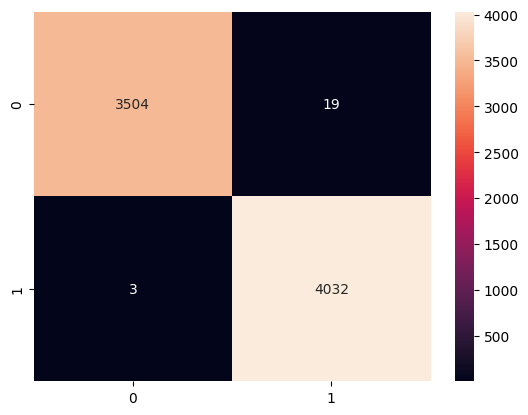

In [ ]:
# Train  model on adversarial data
print("\nTraining New Model on Adversarial Data...")
X_combined = pd.concat([X_train, X_adv])
y_combined = np.concatenate([y_train, y_test])
rf_adv = RandomForestClassifier(n_estimators=100, random_state=42)
rf_adv.fit(X_combined, y_combined)

# Evaluate new model
print("\nAdversarial Model Evaluation:")
evaluate_model(rf_adv, X_test, y_test)

#Auto Encoder


Training Autoencoder-based Adversarial Detector...


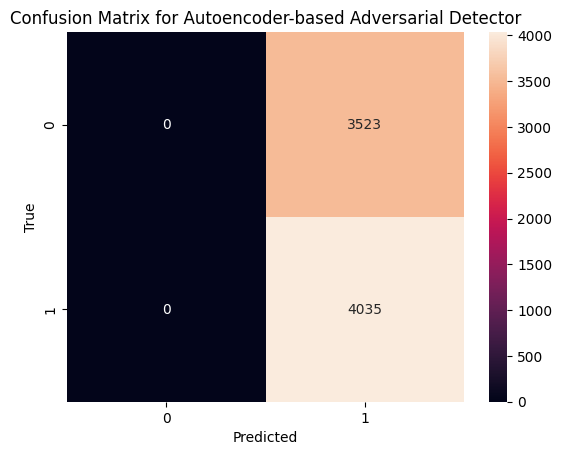

In [ ]:
# Autoencoder-based Adversarial Detection
def train_adversarial_detector(X_clean):
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_clean)

    input_dim = X_scaled.shape[1]
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='sigmoid')(encoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer=Adam(0.001), loss='mse')

    autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, verbose=0)

    reconstructions = autoencoder.predict(X_scaled, verbose=0)
    mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)
    threshold = np.percentile(mse, 95)

    return autoencoder, threshold, scaler

print("\nTraining Autoencoder-based Adversarial Detector...")
detector, threshold, scaler = train_adversarial_detector(X_train)

# Predict on adversarial examples and calculate MSE
X_adv_scaled = scaler.transform(X_adv)
adv_reconstructions = detector.predict(X_adv_scaled, verbose=0)
adv_mse = np.mean(np.power(X_adv_scaled - adv_reconstructions, 2), axis=1)

# Determine adversarial predictions based on threshold
adv_predictions = (adv_mse > threshold).astype(int)

# Generate confusion matrix
cm_adversarial = confusion_matrix(y_test, adv_predictions)

# Plot the confusion matrix
sns.heatmap(cm_adversarial, annot=True, fmt='d')
plt.title('Confusion Matrix for Autoencoder-based Adversarial Detector')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Testing Defense Mechanism on Adversarial Dataset...
Scaling test data...
Reconstructing with autoencoder...
Computing reconstruction error (MSE)...
Using threshold = 0.0005 to identify adversarial samples.


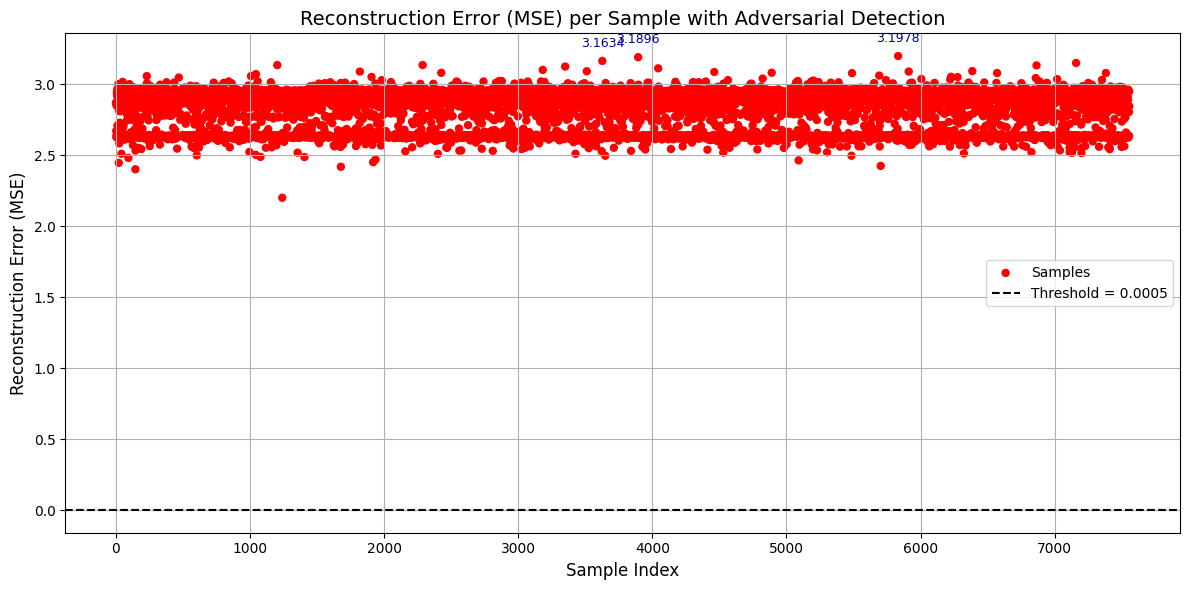

In [ ]:
def defend_against_attack(model, detector, threshold, scaler, X_test):
    print("Scaling test data...")
    X_scaled = scaler.transform(X_test)

    print("Reconstructing with autoencoder...")
    reconstructions = detector.predict(X_scaled, verbose=0)

    print("Computing reconstruction error (MSE)...")
    mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

    print(f"Using threshold = {threshold:.4f} to identify adversarial samples.")
    is_adversarial = mse > threshold

    # Enhanced Plot
    plt.figure(figsize=(12, 6))
    plt.title("Reconstruction Error (MSE) per Sample with Adversarial Detection", fontsize=14)

    colors = ['red' if adv else 'green' for adv in is_adversarial]
    plt.scatter(range(len(mse)), mse, c=colors, s=25, label='Samples')

    plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
    plt.xlabel("Sample Index", fontsize=12)
    plt.ylabel("Reconstruction Error (MSE)", fontsize=12)
    plt.grid(True)
    plt.legend()

    # Annotate top 3 MSE points
    top_indices = np.argsort(mse)[-3:]
    for i in top_indices:
        plt.annotate(f'{mse[i]:.4f}', (i, mse[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='darkblue')

    plt.tight_layout()
    plt.show()

    num_adversarial = np.sum(is_adversarial)
    if num_adversarial > 0:
        print(f"\nWARNING: Detected {num_adversarial} adversarial samples!")
        clean_samples = X_test[~is_adversarial]

        if clean_samples.shape[0] > 0:
            print(f"Proceeding with predictions on {clean_samples.shape[0]} clean samples.")
            return model.predict(clean_samples), is_adversarial
        else:
            return None, is_adversarial
    else:
        print("No adversarial samples detected. Proceeding with all predictions.")
        return model.predict(X_test), is_adversarial


print("\nTesting Defense Mechanism on Adversarial Dataset...")
y_pred_defended, is_adversarial = defend_against_attack(rf, detector, threshold, scaler, X_adv)


Training Robust Model with Adversarial Training...
Epoch 1/5 complete.
Epoch 2/5 complete.
Epoch 3/5 complete.
Epoch 4/5 complete.
Epoch 5/5 complete.

Evaluating Robust Model on Adversarial Dataset:
Accuracy: 0.4661
              precision    recall  f1-score   support

           0       0.47      1.00      0.64      3523
           1       0.00      0.00      0.00      4035

    accuracy                           0.47      7558
   macro avg       0.23      0.50      0.32      7558
weighted avg       0.22      0.47      0.30      7558



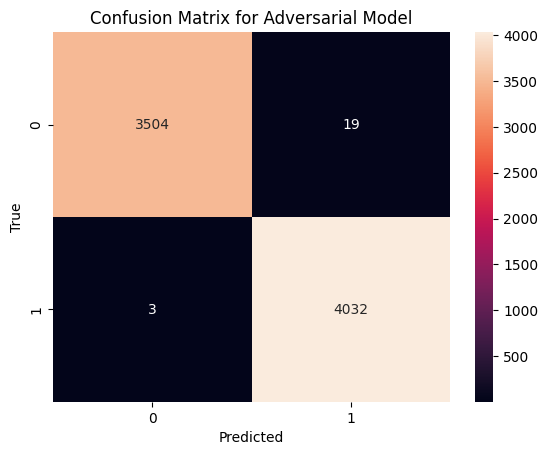

In [ ]:
# Adversarial Training
def adversarial_training(model, X_train, y_train, X_adv, y_adv, epochs=5):
    for epoch in range(epochs):
        X_combined = np.vstack([X_train, X_adv])
        y_combined = np.hstack([y_train, y_adv])
        model.fit(X_combined, y_combined)
        print(f"Epoch {epoch + 1}/{epochs} complete.")
    return model

y_adv = np.zeros(X_adv.shape[0])
print("\nTraining Robust Model with Adversarial Training...")
rf_robust = RandomForestClassifier(n_estimators=100, random_state=42)
rf_robust = adversarial_training(rf_robust, X_train, y_train, X_adv, y_adv)

print("\nEvaluating Robust Model on Adversarial Dataset:")
y_pred_robust = rf_robust.predict(X_adv)
print(f"Accuracy: {accuracy_score(y_test, y_pred_robust):.4f}")
print(classification_report(y_test, y_pred_robust))

y_pred_adv = rf_adv.predict(X_test)
cm_adv = confusion_matrix(y_test, y_pred_adv)

sns.heatmap(cm_adv, annot=True, fmt='d')
plt.title('Confusion Matrix for Adversarial Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
# Evaluate the performance of the robust model on adversarial data
print("\nEvaluating Robust Model on Adversarial Data:")
y_pred_robust_adv = rf_robust.predict(X_adv)

# Calculate reconstruction error and anomaly score for the robust model
X_adv_scaled = scaler.transform(X_adv)
reconstructions_robust_adv = detector.predict(X_adv_scaled)
mse_robust_adv = np.mean(np.power(X_adv_scaled - reconstructions_robust_adv, 2), axis=1)
anomaly_score_robust_adv = mse_robust_adv

# Print the evaluation metrics
print(f"Robust Model Accuracy on Adversarial Data: {accuracy_score(y_test, y_pred_robust_adv):.4f}")
print(f"Average Reconstruction Error (Robust Model, Adversarial Data): {np.mean(mse_robust_adv):.4f}")
print(f"Average Anomaly Score (Robust Model, Adversarial Data): {np.mean(anomaly_score_robust_adv):.4f}")


Evaluating Robust Model on Adversarial Data:
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Robust Model Accuracy on Adversarial Data: 0.4661
Average Reconstruction Error (Robust Model, Adversarial Data): 2.8194
Average Anomaly Score (Robust Model, Adversarial Data): 2.8194
